# Import libraries

In [1]:
# Changes to all modules will automatically be applied when any cell runs. 
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import optuna

from pathlib import Path
import sys

sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
from split_tools import get_train_test

sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling4_utils import (
    BetaVAEncoder,
    MLPipeline,
)

from catboost import CatBoostClassifier
from statsmodels.api import Logit

from sklearn.decomposition import PCA

from sklearn.metrics import (
    make_scorer,
    f1_score,
    mean_squared_error
)

import optuna
from functools import partial



Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.2s
[CV] END .................................................... total time=   1.4s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.8s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
VAE_params: {'latent_dim': 5, 'hidden_dim': 256, 'input_dim': 12, 'verbose': True}
Encoder: Sequential(
  (0): Linear(in_features=12, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.1, inplace=True)
)
Latent space:
	Mu: Linear(in_features=256, out_features=5, bias=True)
	log_sigma2: Linear(in_features=256, out_features=5, bias=T

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 38.
no summary in estimator class "CatBoostClassifier"


,0
target,splashing
model,CatBoostClassifier_splashing_smote_vae
holdout_test_f1_macro,0.855324
holdout_test_accuracy_balanced,0.855324
holdout_test_roc_auc,0.94213
holdout_test_f1,0.895833
holdout_test_accuracy,0.866667
cv_test_f1_macro_median,0.876935
cv_test_accuracy_balanced_median,0.876935
cv_test_roc_auc_median,0.916409


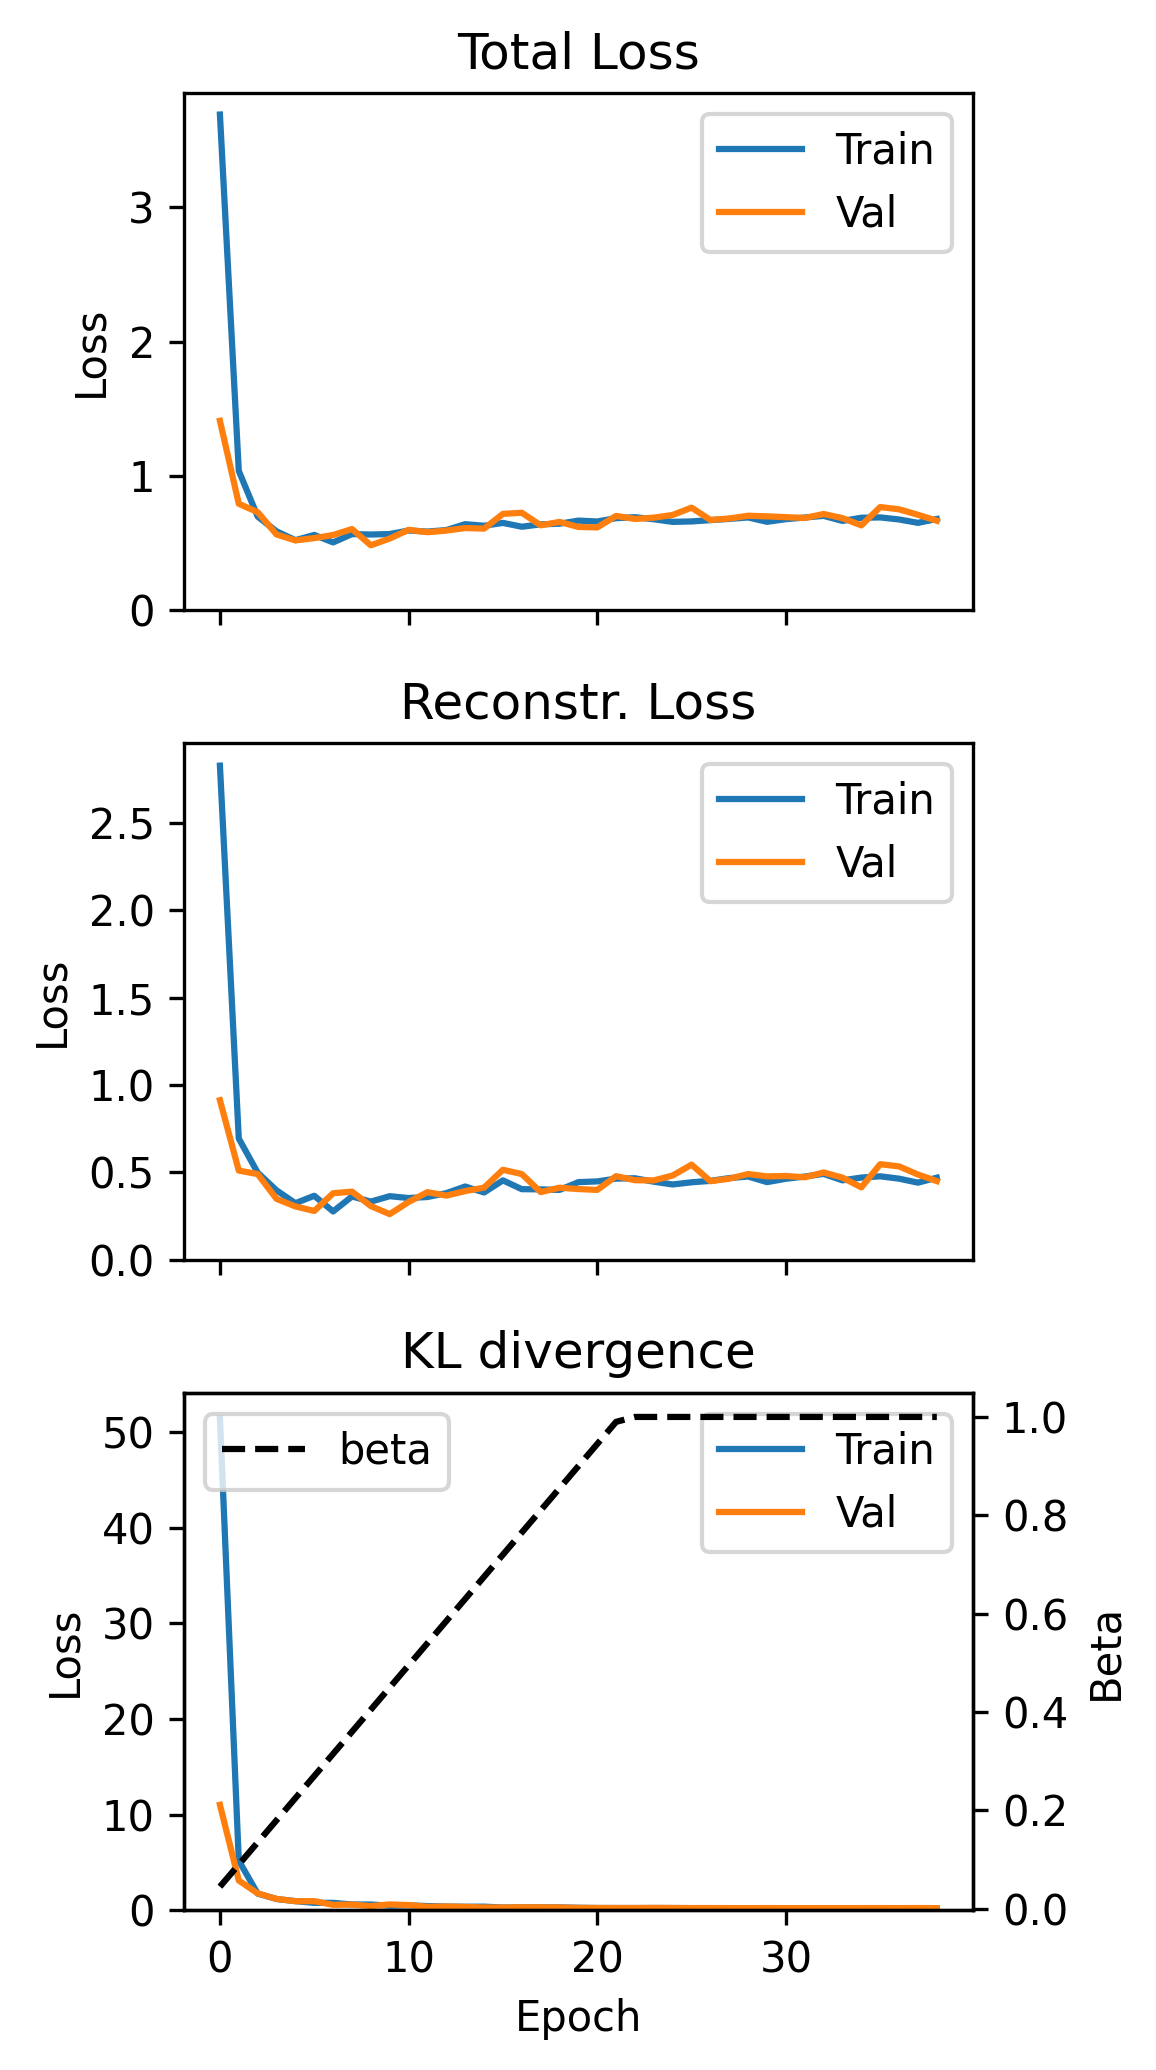

In [3]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'
model_postfix = 'vae'
ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    # post_transformer=PCA,
    # post_transformer_params={'n_components': 6},
    post_transformer=BetaVAEncoder,
    post_transformer_params={
        'VAE_params': {
            'latent_dim': 5,
            'hidden_dim': 256,
        },
        'verbose': True,
        'learning_rate': 5e-2,
        'early_stopping': True,
        'early_stopping_patience': 30,
        # scheduler_class=None,
        'beta_warmup_steps': 200,
        'beta_start': 0.0,
        'beta_end': 1.,
        'max_epochs': 1000,
    },
    features_to_drop=(
        'sign_sedimentation_Re',
        'sign_sedimentation_Stk',
        'sign_particle_droplet_diameter_ratio',
    ),
    cv_folds=7,
    model_postfix=model_postfix,
    verbose=True,
)

# X_train = ml_pipe.train.drop(columns=[target])
# X_test = ml_pipe.test.drop(columns=[target])
# display(X_train.info())
# display(X_test.info())

ml_pipe.run(
    save_model_and_metrics=False,
    cv_verbose=False,
)